# Exploratory Data Analysis


## Goal
1. Investigate top-paying roles and skills in the data science industry.
2. Use Python to explore a 2023 dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.

### Final Deliverables:
- Create Jupyter Notebooks.
- Create a summary page (via README.md) capturing my findings.
- Share this project via GitHub & LinkedIn.

### Questions to Answer
- What are the most demanded skills for the top 3 most popular data roles?
- How are in-demand skills trending for Data Analysts?
- How well do jobs and skills pay for Data Analysts?
- What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)


In [1]:
#Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleanup 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
# Converting job_skills column to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)





# Exploratory Data Analysis for all Data Roles

### Countries to Explore

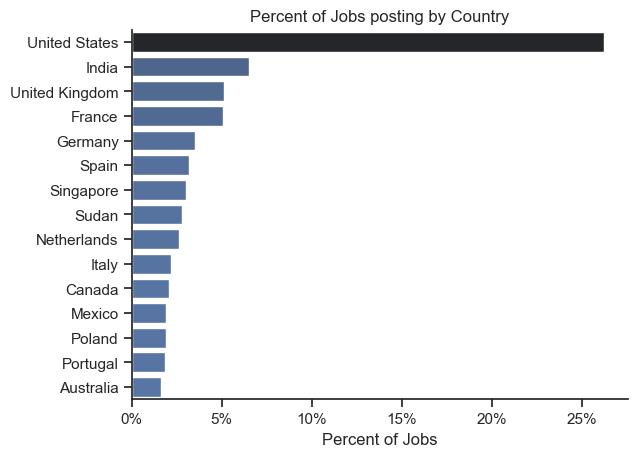

In [2]:
df_plot = df['job_country'].value_counts(normalize = True).mul(100).to_frame(name = 'percent').head(15)

sns.set_theme(style = 'ticks')
sns.barplot(
    data = df_plot, 
    x = 'percent', 
    y= 'job_country', 
    hue = 'percent', 
    palette = "dark:b_r", 
    legend = False)
sns.despine()
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}%'))
plt.title("Percent of Jobs posting by Country")
plt.xlabel('Percent of Jobs')
plt.ylabel('')
plt.show()

### Roles to Explore

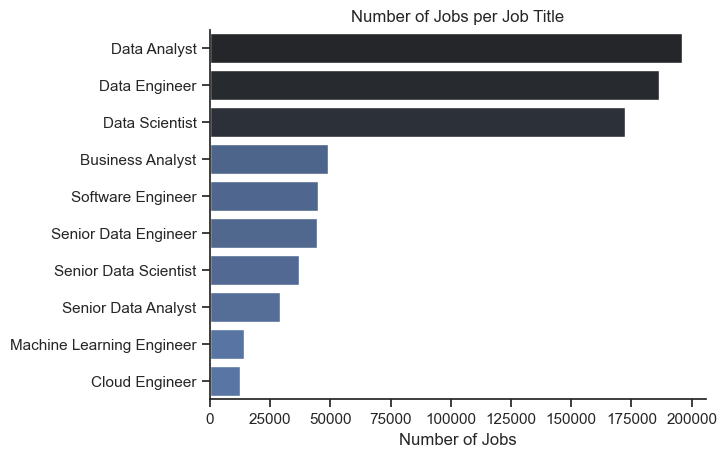

In [3]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot, 
    x='count', 
    y='job_title_short', 
    hue='count', 
    palette='dark:b_r', 
    legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities 


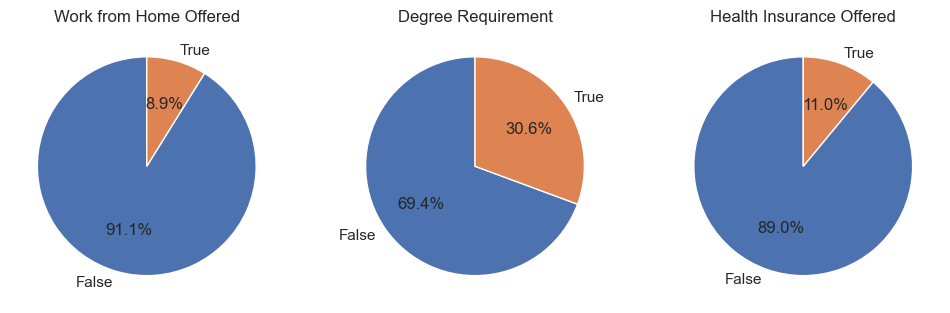

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

# Job from Home
ax[0].pie(df['job_work_from_home'].value_counts(),
          labels=['False', 'True'],
          autopct='%1.1f%%',
          startangle=90)
ax[0].set_title('Work from Home Offered')

# Degree Requirement 
ax[1].pie(df['job_no_degree_mention'].value_counts(),
          labels=['False', 'True'],
          autopct='%1.1f%%',
          startangle=90)
ax[1].set_title('Degree Requirement')

# Health Insurance
ax[2].pie(df['job_health_insurance'].value_counts(),
          labels=['False', 'True'],
          autopct='%1.1f%%',
          startangle=90)
ax[2].set_title('Health Insurance Offered')

plt.show()

# Data Analysis for Data Analyst in the Poland

In [5]:
#Filter foe Poland Data Analyst role
df_pl = df[(df['job_country'] == 'Poland') & (df['job_title_short'] == 'Data Analyst')]


## Location of Jobs

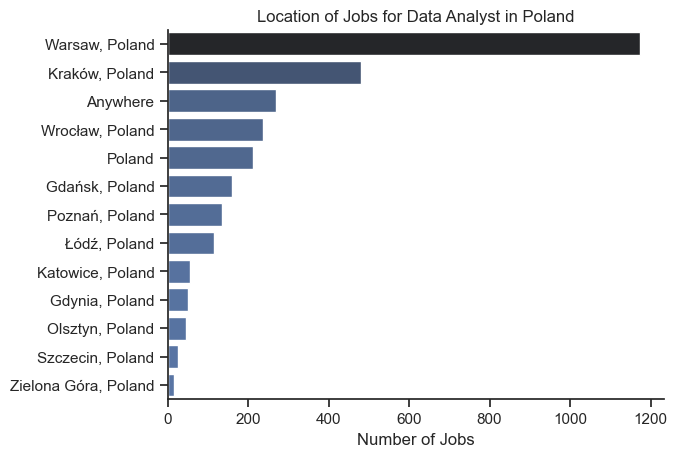

In [10]:
df_plot = df_pl['job_location'].value_counts().head(13).to_frame()

sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot, 
    x='count', 
    y='job_location', 
    hue='count', 
    palette='dark:b_r', 
    legend=False)
sns.despine()
plt.title('Location of Jobs for Data Analyst in Poland')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Companies 

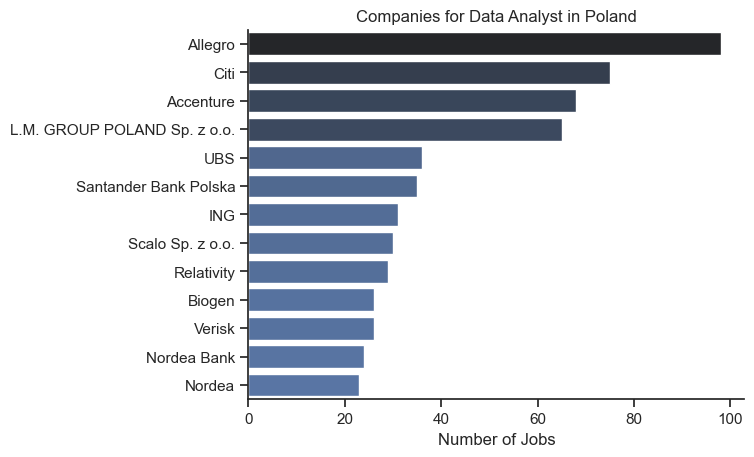

In [11]:
df_plot = df_pl['company_name'].value_counts().head(13).to_frame()

sns.set_theme(style='ticks')
sns.barplot(
    data=df_plot, 
    x='count', 
    y='company_name', 
    hue='count', 
    palette='dark:b_r', 
    legend=False)
sns.despine()
plt.title('Companies for Data Analyst in Poland')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()
